# Análise do motivo "OUTROS"

* Criação de uma matriz de semelhança entre os motivos existentes com as justificativas do motivo "OUTROS".
* Análise descritiva da justificativa "OUTROS".

In [ ]:
#Bilbiotecas utilizadas (Parte 1)
!pip install pandas numpy sentence-transformers scikit-learn tqdm umap-learn hdbscan --trusted-host pypi.org --trusted-host files.pythonhosted.org --trusted-host pypi.python.org

In [ ]:
#Bilbiotecas utilizadas (Parte 2)
!pip install hdbscan --user

## Imports

In [15]:
# --- BIBLIOTECAS DE SUPORTE E MANIPULAÇÃO ---
from sentence_transformers import SentenceTransformer      # Carrega a rede neural localmente
from sklearn.metrics.pairwise import cosine_similarity     # Calcula o ângulo vetorial
import numpy as np                                         # Operações matemáticas e manipulação de arrays/matrizes
import pandas as pd                                        # Manipulação, limpeza e análise de dados tabulares
import re                                                  # Expressões regulares para limpeza e padronização
import unicodedata                                         # Normalização de caracteres e remoção de acentuação
import matplotlib.pyplot as plt                            # Para visualizarmos o gráfico de Pareto e Histogramas
import seaborn as sns                                      # Para descritiva visual elegante

# --- CONFIGURAÇÕES DO AMBIENTE ---
import warnings
warnings.filterwarnings("ignore")  # Suprime alertas de sistema para manter o output limpo
pd.set_option('display.max_columns', None)
# Define a largura máxima da coluna como ilimitada (None) ou um valor alto (ex: 500)
pd.set_option('display.max_colwidth', None)
# Opcional: Se quiser ver mais linhas de uma vez para validar a limpeza
pd.set_option('display.max_rows', 20)

## Carregamento do Modelo de Embedding

In [2]:
# --- FASE 1: INICIALIZAÇÃO DA INTELIGÊNCIA ARTIFICIAL ---

print("1/4: Carregando a Rede Neural Localmente...")
# O algoritmo acessa os pesos e o dicionário diretamente no disco local
modelo = SentenceTransformer('./modelo_minilm/')

print(f"✅ Sucesso! Modelo carregado com limite de {modelo.max_seq_length} tokens.")

1/4: Carregando a Rede Neural Localmente...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Sucesso! Modelo carregado com limite de 128 tokens.


## Saneamento do texto

In [3]:
def pre_processar_texto_universal(texto):
    """
    Função ÚNICA e correta para usar TANTO nos Motivos Oficiais quanto nas Justificativas.
    """
    if not isinstance(texto, str):
        return ""
    
    # 1. Tudo para minúsculo
    texto = texto.lower()
    
    # 2. Remoção de acentos (Normalização Unicode)
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    
    # 3. Mantém apenas letras (a-z), números (0-9) e espaços.
    # (Removemos estritamente símbolos como / - . " que quebram a matemática)
    texto = re.sub(r'[^a-z0-9\s]', ' ', texto)
    
    # 4. Remove espaços extras
    texto = " ".join(texto.split())
    
    return texto

# 1 - Importação e tratamento dos dados

## 1.1 Tabela referente as justificativas do motivo OUTROS

* Período dos dados: **Janeiro de 2025** até **Maio de 2026**.

In [4]:
#Tabela das justificativas dos OUTROS
df = pd.read_csv('motivo_outros.csv', engine='python', encoding='utf-16', sep=',', on_bad_lines='skip')
#Visualização
df.head(3)

,prot_nu,unidprot_cd,nf_tp_registro,nf_sq_registro,cnpj,inscricao_estadual,cnae_principal_numero,cnae_principal_descricao,segmento_economico,regime_contrib.,ano_mes,gafdemanda_dt_geracao,gafdemanda_dt_inicio_exec,gafdemanda_dt_fim_exec,proccontst_in_dentro_prazo,valor_nota,total_items_perspectiva,total_items_nota,cmtmotivo_cd,cmtmotivo_ds,procontenf_tx_justificativa,valor_cobrado,valor_sugerido_contrib,sitprot_cd
0,202500000007847912,12,6,297687286,24596334000138,84511761,54652400,"COMERCIO POR ATACADO, EXCETO VEICULOS AUTOMOTO...",ATACADO,SIMPLES NACIONAL,2025-01,2025-01-02,2025-03-03,2025-03-03,N,2321.93,1.0,18.00,214,OUTROS,MVA DIVERGENTE / A MAIOR. CONFORME CONFERIDO N...,353.64,353.64,1
1,202500000007847912,12,6,299382838,24596334000138,84511761,54652400,"COMERCIO POR ATACADO, EXCETO VEICULOS AUTOMOTO...",ATACADO,SIMPLES NACIONAL,2025-01,2025-01-02,2025-03-03,2025-03-03,N,13888.34,1.0,2.00,214,OUTROS,NFE DEVOLVIDA. CHAVE DE DEVOLUÇÃO: 3524 1203 3...,4510.75,0.00,1
2,202500000008128154,12,6,307302767,55811359000130,118199870,54687703,"COMERCIO POR ATACADO, EXCETO VEICULOS AUTOMOTO...",ATACADO,NORMAL,2025-01,2025-01-02,2025-07-29,2025-07-29,N,130000.00,1.0,92857.14,214,OUTROS,NFS,22075.47,0.00,2


In [5]:
#Volumetria
volumetria = df.shape[0] 
print(f"Volumetria: {volumetria}") #240.061

Volumetria: 240061


In [ ]:
#Período dos dados
df.groupby('ano_mes').size()

### Lapidação textual

In [6]:
##Saneamento do texto
df['justificativa_limpa'] = df['procontenf_tx_justificativa'].fillna('sem_justificativa_informada').apply(pre_processar_texto_universal) #Feature Textual Principal
##Variável total de palavras da justificativa - aplicada na justificativa limpa
df['total_palavras'] = df['justificativa_limpa'].fillna("").apply(lambda x: len(str(x).split()))

**Volumetria de Palavras**

In [8]:
#Descritiva do total de palavras
df['total_palavras'].describe(percentiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

count    240061.000000
mean         39.786159
std          54.053425
min           0.000000
10%           5.000000
20%           9.000000
30%          12.000000
40%          16.000000
50%          21.000000
60%          28.000000
70%          38.000000
80%          53.000000
90%          96.000000
max         638.000000
Name: total_palavras, dtype: float64

In [12]:
# Calcular percentis de 95 a 99 (passo de 1)
percentis = [95, 96, 97, 98, 99]
resultado = df['total_palavras'].quantile([p/100 for p in percentis])

print(resultado)

0.95    150.0
0.96    170.0
0.97    216.0
0.98    216.0
0.99    271.0
Name: total_palavras, dtype: float64


### Até o Percentil 50

**Insight**: São textos curtos. Provavelmente o contribuinte sabe o que quer, mas o sistema falhou em apresentar o botão correto. Ele está usando o "Outros" como um atalho rápido para uma categoria que deveria ser óbvia.

### Zona do problema

* **"Zona de Taxonomia" (P80 ao P90)**: O volume de palavras quase dobra, saltando de 53 para 96 palavras.
* **Insight**: Aqui estão os casos onde o sistema realmente "vaza". O usuário precisa de quase 100 palavras para explicar um cenário que a SEFAZ não previu.

**Volumetria de Tokens**

In [11]:
# --- CORREÇÃO DA CONTAGEM DE TOKENS (SISTEMATIZADA) ---

print("Recalculando tokens reais...")

# Usamos o tokenizer diretamente para acessar a lista de IDs
# O método 'encode' do tokenizer (não do modelo) nos dá a lista real
df['qtd_tokens'] = df['justificativa_limpa'].apply(lambda x: len(modelo.tokenizer.encode(str(x), add_special_tokens=False)))

print("✅ Nova Descritiva de Tokens:")
print(df['qtd_tokens'].describe(percentiles=[0.1, 0.5, 0.9, 0.95, 0.99]))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (177 > 128). Running this sequence through the model will result in indexing errors


Recalculando tokens reais...
✅ Nova Descritiva de Tokens:
count    240061.000000
mean         57.982096
std          85.364371
min           0.000000
10%           7.000000
50%          31.000000
90%         135.000000
95%         206.000000
99%         423.000000
max        1013.000000
Name: qtd_tokens, dtype: float64


## Data frame final das justificativas

In [13]:
# --- FASE DE HIGIENIZAÇÃO ESTRUTURAL ---

# 1. Aplicando a dupla trava (Negócio + Técnica)
df_final = df[
    (df['total_palavras'] > 3) &       # Perspectiva 1: Mínimo de conteúdo
    (df['qtd_tokens'] <= 210)          # Perspectiva 2: Limite de leitura da IA
].copy()

# 2. Configurando o modelo para ler exatamente o que definimos
# Embora o P95 seja 210, usamos 256 por eficiência computacional (potência de 2)
modelo.max_seq_length = 256

percentual = (len(df_final) / len(df)) * 100
print(f"📊 Base Limpa: {len(df_final):,} registros ({percentual:.2f}% da base original)")

📊 Base Limpa: 214,263 registros (89.25% da base original)


In [17]:
#Visualização
df_final[['prot_nu', 'unidprot_cd', 'nf_tp_registro' ,'nf_sq_registro','justificativa_limpa']].head(16)

,prot_nu,unidprot_cd,nf_tp_registro,nf_sq_registro,justificativa_limpa
0,202500000007847912,12,6,297687286,mva divergente a maior conforme conferido na tabela de mva de produtos eletronicos eletroeletronicos e eletrodomesticos o ncm 8525 8929 foi reduzido a partir de 1 de maio de 2024 conulta em https www sefaz pe gov br legislacao tributaria documents legislacao tabelas tabela 20mva 20produtos 20eletr c3 b4nicos 20a 20partir 20de 201 c2 ba 5 24 pdf codigo 1071 valor da nf r 2 321 93 agreg 32 83 icms 278 63
1,202500000007847912,12,6,299382838,nfe devolvida chave de devolucao 3524 1203 3173 4200 0128 5500 3000 7175 8317 7888 4508
6,202500000008218145,12,6,296324276,as notas refere se a transferencias de materias entre filiais para uso e consumo
7,202500000008218145,12,6,296857830,as notas refere se a transferencias de materias entre filiais para uso e consumo
8,202500000008218145,12,6,299726235,as notas refere se a transferencias de materias entre filiais para uso e consumo
9,202500000008218145,12,6,296275081,as notas refere se a transferencias de materias entre filiais para uso e consumo
10,202500000008218145,12,6,297790291,as notas refere se a transferencias de materias entre filiais para uso e consumo
11,202500000008218145,12,6,299142480,as notas refere se a transferencias de materias entre filiais para uso e consumo
12,202500000008218145,12,6,296591523,as notas refere se a transferencias de materias entre filiais para uso e consumo
13,202500000008261581,12,6,305307882,aquisicao por comerciante do simples nacional empresa de pequeno porte epp que nao trabalha com produtos do segmentos de material de construcao regular nos termos da portaria sf no 198 2017 ou do art 339 a do decreto no 44 650 2017 de mercadoria nao sujeita a st e destinada a comercializacao contribuinte enquadrado no inciso ii do artigo 329 e no item 2 da alinea a do inciso iii do artigo 363 a do decreto no 44 650 2017 em virtude disto as mercadorias com ncm 39173100 foram calculadas conforme item 2 da alinea a do inciso iii do artigo 363 a do decreto no 44 650 2017 considerando o percentual de reducao de 6 37 tendo em vista que a aliquota interestadual e de 12 e a aliquota interna de 20 5


In [18]:
#Limpeza antes da vetorização
# --- AJUSTE FINO: FOCO NO SIGNIFICADO (REMOÇÃO DE RUÍDO NUMÉRICO) ---

def limpeza_semantica(texto):
    # 1. Remove URLs (http, https, www)
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)
    # 2. Remove sequências numéricas longas (chaves de NF, CPFs, etc - mais de 6 dígitos)
    texto = re.sub(r'\b\d{7,}\b', '', texto)
    # 3. Remove excesso de espaços em branco
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df_final['justificativa_vetor'] = df_final['justificativa_limpa'].apply(limpeza_semantica)

# Visualizando a diferença
print("Original:", df_final['justificativa_limpa'].iloc[1])
print("Para Vetorização:", df_final['justificativa_vetor'].iloc[1])

Original: nfe devolvida chave de devolucao 3524 1203 3173 4200 0128 5500 3000 7175 8317 7888 4508
Para Vetorização: nfe devolvida chave de devolucao 3524 1203 3173 4200 0128 5500 3000 7175 8317 7888 4508


### Vetorização

In [19]:
# --- FASE 1: GERAÇÃO DA MATRIZ SEMÂNTICA (EMBEDDINGS) ---

print(f"🚀 Iniciando vetorização de {len(df_final):,} justificativas...")
print(f"📏 Dimensão final esperada: ({len(df_final):,}, 384)")

# O modelo processará em blocos de 64 frases para otimizar a memória
# convert_to_numpy=True garante que teremos uma matriz pronta para cálculos estatísticos
embeddings = modelo.encode(
    df_final['justificativa_vetor'].astype(str).tolist(), 
    batch_size=64, 
    show_progress_bar=True, 
    convert_to_numpy=True
)

print("\n✅ Vetorização concluída com sucesso!")
print(f"💎 Matriz 'embeddings' criada: {embeddings.shape}")

# Uma pequena amostra do primeiro vetor (os primeiros 5 números das 384 dimensões)
print(f"Amostra do primeiro vetor: {embeddings[0][:5]}")

🚀 Iniciando vetorização de 214,263 justificativas...
📏 Dimensão final esperada: (214,263, 384)


Batches:   0%|          | 0/3348 [00:00<?, ?it/s]


✅ Vetorização concluída com sucesso!
💎 Matriz 'embeddings' criada: (214263, 384)
Amostra do primeiro vetor: [-0.08898518  0.37768126  0.09604267 -0.01324427  0.12683794]


In [20]:
# --- SALVAMENTO AUTOMÁTICO PÓS-VETORIZAÇÃO ---

try:
    # 1. Salva a matriz de Embeddings (384D) em formato binário otimizado
    np.save('embeddings_sefaz_full.npy', embeddings)
    
    # 2. Salva o DataFrame higienizado para manter a paridade com os vetores
    df_final.to_csv('df_final_processado.csv', index=False)
    
    print("\n" + "="*40)
    print("💾 BACKUP AUTOMÁTICO CONCLUÍDO!")
    print(f"📂 Arquivo de vetores: embeddings_sefaz_full.npy")
    print(f"📂 Arquivo de dados: df_final_processado.csv")
    print("="*40)

except NameError:
    print("⚠️ Erro: A variável 'embeddings' ainda não foi gerada.")
except Exception as e:
    print(f"❌ Ocorreu um erro no salvamento: {e}")


💾 BACKUP AUTOMÁTICO CONCLUÍDO!
📂 Arquivo de vetores: embeddings_sefaz_full.npy
📂 Arquivo de dados: df_final_processado.csv


## 1.2 Tabela referente aos motivos de contestação

In [28]:
#Tabela das justificativas dos OUTROS
df_motivos = pd.read_csv('motivos_contestacao.csv', engine='python', encoding='utf-16', sep=',', on_bad_lines='skip')
#Visualização
df_motivos.head(3)

,cmtmotivo_ds
0,CONVÊNIO 01/99
1,CARGA RECUPERADA
2,PRODUTO GOZA DE IMUNIDADE/NAO-INCIDENCIA


In [29]:
#Volumetria
df_motivos.shape[0] #322

322

In [30]:
# 1. Aplicar a sua função universal na lista de motivos
df_motivos['motivo_limpo'] = df_motivos['cmtmotivo_ds'].apply(pre_processar_texto_universal)

# 2. Remover o 'outros' e duplicatas
df_motivos_vivos = df_motivos[df_motivos['motivo_limpo'] != 'outros'].copy()
lista_motivos_unicos = df_motivos_vivos['motivo_limpo'].unique().tolist()

In [31]:
#Visualização
df_motivos.head(30)

,cmtmotivo_ds,motivo_limpo
0,CONVÊNIO 01/99,convenio 01 99
1,CARGA RECUPERADA,carga recuperada
2,PRODUTO GOZA DE IMUNIDADE/NAO-INCIDENCIA,produto goza de imunidade nao incidencia
3,REMESSA/RETORNO DE INDUSTRIALIZAÇÃO,remessa retorno de industrializacao
4,INSUMO PARA INDÚSTRIA,insumo para industria
...,...,...
25,"VEÍCULOS NOVOS, ALÍQUOTA REDUZIDA DE 12% - ART. 18, I, 'A', LEI 15.730/2016",veiculos novos aliquota reduzida de 12 art 18 i a lei 15 730 2016
26,"RAÇÃO PARA ANIMAIS DOMÉSTICOS, ARTS 55 E 56, ANEXO 37, DECRETO 44.650/2017.",racao para animais domesticos arts 55 e 56 anexo 37 decreto 44 650 2017
27,CRENDENCIAMENTO MASSAS E BISCOITOS PORT. 072/2007 E PORT. 192/2011,crendenciamento massas e biscoitos port 072 2007 e port 192 2011
28,DANFE CANCELADO PELO EMITENTE,danfe cancelado pelo emitente


### Vetorização

In [32]:
# 3. Vetorizar os alvos (os motivos oficiais limpos)
embeddings_motivos = modelo.encode(lista_motivos_unicos)

# 2 - Distância do Cosseno

**Matemática de comparação**

In [35]:
# --- FASE DE PAREAMENTO SEMÂNTICO ---
print(f"🎯 Calculando proximidade para {len(df_final):,} justificativas contra {len(lista_motivos_unicos)} motivos...")

# 1. Cálculo da Similaridade de Cosseno (Matriz de 214k x 317)
matriz_sim = cosine_similarity(embeddings, embeddings_motivos)

# 2. Identificação do Melhor Match
# np.argmax pega o índice do motivo com maior score
indices_vencedores = np.argmax(matriz_sim, axis=1)
scores_confianca = np.max(matriz_sim, axis=1)

# 3. Registro dos Resultados no DataFrame
df_final['motivo_ia_sugerido'] = [lista_motivos_unicos[i] for i in indices_vencedores]
df_final['confianca_ia'] = scores_confianca

print("✅ Mapeamento concluído!")

🎯 Calculando proximidade para 214,263 justificativas contra 313 motivos...
✅ Mapeamento concluído!


In [36]:
# --- TABELA DE FREQUÊNCIA: O DIAGNÓSTICO DO 'OUTROS' ---

print("📊 DISTRIBUIÇÃO SEMÂNTICA (O QUE O USUÁRIO REALMENTE QUERIA DIZER):")
print("-" * 60)

# Calculando Frequência Absoluta e Percentual
contagem = df_final['motivo_ia_sugerido'].value_counts()
percentual = df_final['motivo_ia_sugerido'].value_counts(normalize=True) * 100

# Criando o DataFrame de Diagnóstico para exibição
df_diagnostico = pd.DataFrame({
    'Quantidade': contagem,
    'Percentual (%)': percentual.round(2)
}).head(20) # Mostra os 20 principais motivos que estavam "escondidos"

display(df_diagnostico)

# Insight Automático
top_motivo = df_diagnostico.index[0]
top_perc = df_diagnostico.iloc[0, 1]
print(f"\n💡 CONCLUSÃO: O motivo '{top_motivo}' representa {top_perc}% do volume que hoje cai em 'Outros'.")

📊 DISTRIBUIÇÃO SEMÂNTICA (O QUE O USUÁRIO REALMENTE QUERIA DIZER):
------------------------------------------------------------


,Quantidade,Percentual (%)
motivo_ia_sugerido,,
nota fiscal indevido o icms antecipado,11981,5.59
mercadoria com icms recolhido por subst tributaria,7931,3.70
nota fiscal com icms antecipado pago,6460,3.01
mercadoria sujeita a nao incidencia do icms,6333,2.96
remessa de mercadoria ou bem para conserto art 524 decreto 44 650 2017,6106,2.85
icms recolhido na nf emitida pelo armazem geral logistica a partir de 10 17 art 486 dec 44650 17,4990,2.33
nf destinada a contribuinte nao sujeito a antecipacao tributaria,4817,2.25
mercadoria paga atraves de substituicao tributaria,4748,2.22
insumo para industria prod subst tributaria clausula nona inc iii convenio 142 2018,4623,2.16



💡 CONCLUSÃO: O motivo 'nota fiscal indevido o icms antecipado' representa 5.59% do volume que hoje cai em 'Outros'.


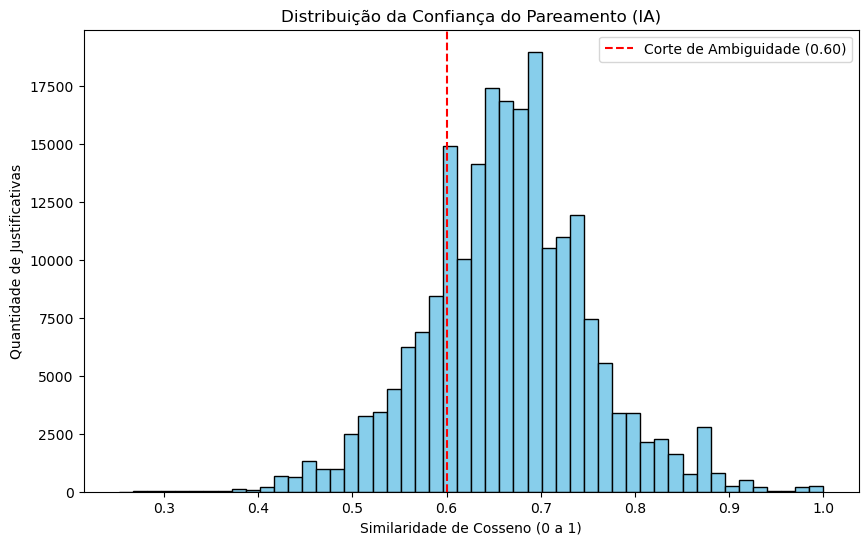

⚠️ Alerta: 44675 justificativas (20.85%) não possuem um motivo correspondente claro no sistema.


In [38]:
# --- HISTOGRAMA DE CONFIANÇA SEMÂNTICA ---
plt.figure(figsize=(10, 6))
plt.hist(df_final['confianca_ia'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(x=0.6, color='red', linestyle='--', label='Corte de Ambiguidade (0.60)')
plt.title('Distribuição da Confiança do Pareamento (IA)')
plt.xlabel('Similaridade de Cosseno (0 a 1)')
plt.ylabel('Quantidade de Justificativas')
plt.legend()
plt.show()

# Estatística de Ambiguidade
orfaos = df_final[df_final['confianca_ia'] < 0.60].shape[0]
print(f"⚠️ Alerta: {orfaos} justificativas ({orfaos/len(df_final)*100:.2f}%) não possuem um motivo correspondente claro no sistema.")

In [37]:
df_final.head(3)

,prot_nu,unidprot_cd,nf_tp_registro,nf_sq_registro,cnpj,inscricao_estadual,cnae_principal_numero,cnae_principal_descricao,segmento_economico,regime_contrib.,ano_mes,gafdemanda_dt_geracao,gafdemanda_dt_inicio_exec,gafdemanda_dt_fim_exec,proccontst_in_dentro_prazo,valor_nota,total_items_perspectiva,total_items_nota,cmtmotivo_cd,cmtmotivo_ds,procontenf_tx_justificativa,valor_cobrado,valor_sugerido_contrib,sitprot_cd,justificativa_limpa,total_palavras,qtd_tokens,justificativa_vetor,motivo_ia_sugerido,confianca_ia
0,202500000007847912,12,6,297687286,24596334000138,84511761,54652400,"COMERCIO POR ATACADO, EXCETO VEICULOS AUTOMOTORES E MOTOCICLETAS",ATACADO,SIMPLES NACIONAL,2025-01,2025-01-02,2025-03-03,2025-03-03,N,2321.93,1.0,18.0,214,OUTROS,"MVA DIVERGENTE / A MAIOR. CONFORME CONFERIDO NA TABELA DE MVA DE PRODUTOS ELETRONICOS, ELETROELETRÔNICOS E ELETRODOMÉSTICOS O NCM 8525.8929 FOI REDUZIDO A PARTIR DE 1° DE MAIO DE 2024. CONULTA EM: HTTPS://WWW.SEFAZ.PE.GOV.BR/LEGISLACAO/TRIBUTARIA/DOCUMENTS/LEGISLACAO/TABELAS/TABELA%20MVA%20PRODUTOS%20ELETR%C3%B4NICOS_%20A%20PARTIR%20DE%201%C2%BA.5.24.PDF CÓDIGO 1071 VALOR DA NF: R$ 2.321,93 AGREG: 32,83% ICMS: 278,63",353.64,353.64,1,mva divergente a maior conforme conferido na tabela de mva de produtos eletronicos eletroeletronicos e eletrodomesticos o ncm 8525 8929 foi reduzido a partir de 1 de maio de 2024 conulta em https www sefaz pe gov br legislacao tributaria documents legislacao tabelas tabela 20mva 20produtos 20eletr c3 b4nicos 20a 20partir 20de 201 c2 ba 5 24 pdf codigo 1071 valor da nf r 2 321 93 agreg 32 83 icms 278 63,73,125,mva divergente a maior conforme conferido na tabela de mva de produtos eletronicos eletroeletronicos e eletrodomesticos o ncm 8525 8929 foi reduzido a partir de 1 de maio de 2024 conulta em www sefaz pe gov br legislacao tributaria documents legislacao tabelas tabela 20mva 20produtos 20eletr c3 b4nicos 20a 20partir 20de 201 c2 ba 5 24 pdf codigo 1071 valor da nf r 2 321 93 agreg 32 83 icms 278 63,produtos eletro eletronicos a partir de 01 06 18 decreto 46028 18,0.739563
1,202500000007847912,12,6,299382838,24596334000138,84511761,54652400,"COMERCIO POR ATACADO, EXCETO VEICULOS AUTOMOTORES E MOTOCICLETAS",ATACADO,SIMPLES NACIONAL,2025-01,2025-01-02,2025-03-03,2025-03-03,N,13888.34,1.0,2.0,214,OUTROS,NFE DEVOLVIDA. CHAVE DE DEVOLUÇÃO: 3524 1203 3173 4200 0128 5500 3000 7175 8317 7888 4508,4510.75,0.00,1,nfe devolvida chave de devolucao 3524 1203 3173 4200 0128 5500 3000 7175 8317 7888 4508,16,30,nfe devolvida chave de devolucao 3524 1203 3173 4200 0128 5500 3000 7175 8317 7888 4508,remessa em garantia assistencia tecnica cred inc ii alinea e item 5 da port 147 2008,0.650004
6,202500000008218145,12,6,296324276,27093558008442,103844996,57739099,ALUGUEIS NAO-IMOBILIARIOS E GESTAO DE ATIVOS INTANGIVEIS NAO-FINANCEIROS,ATACADO,NORMAL,2025-01,2025-01-02,2025-03-03,2025-03-03,N,386.41,1.0,2.0,214,OUTROS,AS NOTAS REFERE-SE A TRANSFERENCIAS DE MATERIAS ENTRE FILIAIS PARA USO E CONSUMO.,65.62,0.00,1,as notas refere se a transferencias de materias entre filiais para uso e consumo,14,17,as notas refere se a transferencias de materias entre filiais para uso e consumo,mercadoria paga atraves de substituicao tributaria,0.587164


In [39]:
#Salvar os arquivos
df_final.to_csv('justificativa_outros_similaridades.csv', index=False, encoding = 'utf-8')